In [1]:
!pip install pandas scikit-learn nltk

In [2]:
import pandas as pd
import numpy as np
import nltk
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


In [3]:
nltk.download('stopwords')
from nltk.corpus import stopwords


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [4]:
from google.colab import files
uploaded = files.upload()


Saving FakeNewsNet.csv.zip to FakeNewsNet.csv.zip


In [5]:
df = pd.read_csv("FakeNewsNet.csv.zip")
df.head()


,title,news_url,source_domain,tweet_num,real
0,Kandi Burruss Explodes Over Rape Accusation on...,http://toofab.com/2017/05/08/real-housewives-a...,toofab.com,42,1
1,People's Choice Awards 2018: The best red carp...,https://www.today.com/style/see-people-s-choic...,www.today.com,0,1
2,Sophia Bush Sends Sweet Birthday Message to 'O...,https://www.etonline.com/news/220806_sophia_bu...,www.etonline.com,63,1
3,Colombian singer Maluma sparks rumours of inap...,https://www.dailymail.co.uk/news/article-33655...,www.dailymail.co.uk,20,1
4,Gossip Girl 10 Years Later: How Upper East Sid...,https://www.zerchoo.com/entertainment/gossip-g...,www.zerchoo.com,38,1


In [6]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df['title'] = df['title'].apply(clean_text)



In [7]:
X = df['title']     # text column
y = df['real']      # label column


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [9]:
vectorizer = TfidfVectorizer(max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


In [10]:
model = LogisticRegression()
model.fit(X_train_vec, y_train)


LogisticRegression()

In [11]:
y_pred = model.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.8284482758620689
              precision    recall  f1-score   support

           0       0.75      0.44      0.56      1131
           1       0.84      0.95      0.89      3509

    accuracy                           0.83      4640
   macro avg       0.80      0.70      0.72      4640
weighted avg       0.82      0.83      0.81      4640



In [12]:
news = ["Breaking: Government announces new policy"]

news_vec = vectorizer.transform(news)
prediction = model.predict(news_vec)

print("Prediction:", prediction)


Prediction: [1]


In [13]:
df['real'].value_counts()


,count
real,
1,17441
0,5755


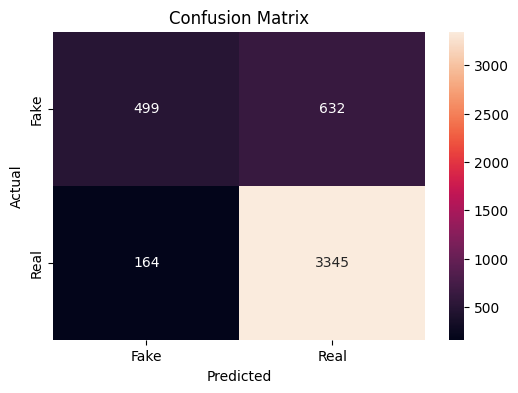

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [22]:
# Import
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train model
nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)

# Predict
y_pred_nb = nb_model.predict(X_test_vec)

# Accuracy
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

# Report
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))



Naive Bayes Accuracy: 0.8306034482758621

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.43      0.55      1131
           1       0.84      0.96      0.90      3509

    accuracy                           0.83      4640
   macro avg       0.81      0.70      0.72      4640
weighted avg       0.82      0.83      0.81      4640



In [21]:
# Import
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train model
svm_model = LinearSVC()
svm_model.fit(X_train_vec, y_train)

# Predict
y_pred_svm = svm_model.predict(X_test_vec)

# Accuracy
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

# Report
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

# Confusion Matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))


SVM Accuracy: 0.8275862068965517

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.56      0.61      1131
           1       0.87      0.91      0.89      3509

    accuracy                           0.83      4640
   macro avg       0.77      0.74      0.75      4640
weighted avg       0.82      0.83      0.82      4640


Confusion Matrix:
 [[ 632  499]
 [ 301 3208]]
